In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from gammatone.filters import make_erb_filters, erb_filterbank, centre_freqs
from brian2 import *
import glob
import os

In [2]:
# ==============================
# Find all wav files
# ==============================
wav_files = sorted(glob.glob("datasets/vox1_small/**/*.wav", recursive=True))
print(f"Total files found: {len(wav_files)}")

MAX_SAMPLES = 30  # limit for testing convergence; increase for full training
wav_files = wav_files[:MAX_SAMPLES]
print(f"Training on: {len(wav_files)} samples")
print("Example:", wav_files[0] if wav_files else "(none)")

Total files found: 19602
Training on: 30 samples
Example: datasets/vox1_small/id10001/id10001_00001/00001.wav


In [3]:
# ==============================
# Audio → Input Current Matrix
# (same encoding pipeline as main.ipynb)
# ==============================
def compute_input_current(audio_path, sr=16000, num_filters=100, f_min=50,
                           sustained_per_band=5, onset_per_band=2, phase_per_band=2,
                           SCALE=1.2, pct=95):
    """
    Returns:
        I : (N_in, T) float array of input currents
        T : number of time steps
    """
    signal, _ = librosa.load(audio_path, sr=sr)

    # Gammatone filterbank
    cf = centre_freqs(sr, num_filters, f_min)
    erb_filters = make_erb_filters(sr, cf)
    filtered = erb_filterbank(signal, erb_filters)
    cf = cf[::-1]
    filtered = filtered[::-1]

    n_channels, T = filtered.shape

    # IHC log compression
    E = np.log1p(4.0 * np.maximum(filtered, 0))

    # Onset detection
    dE = np.diff(E, axis=1, prepend=E[:, :1])
    dE[dE < 0] = 0

    # Phase signal
    phase = np.maximum(filtered, 0)

    # Per-signal gain normalization
    E_95     = max(np.percentile(E,     pct), 1e-6)
    dE_95    = max(np.percentile(dE,    pct), 1e-6)
    phase_95 = max(np.percentile(phase, pct), 1e-6)

    g_sust  = 1.3 / E_95
    g_onset = 2.0 / dE_95
    g_phase = 1.0 / phase_95

    neurons_per_band = sustained_per_band + onset_per_band + phase_per_band
    N_in = n_channels * neurons_per_band
    I = np.zeros((N_in, T), dtype=np.float32)
    idx = 0

    for ch in range(n_channels):
        spread = np.linspace(0.6, 1.4, sustained_per_band)
        for mult in spread:
            I[idx] = g_sust * mult * SCALE * E[ch]
            idx += 1
        for _ in range(onset_per_band):
            I[idx] = g_onset * SCALE * dE[ch]
            idx += 1
        for _ in range(phase_per_band):
            I[idx] = g_phase * SCALE * phase[ch]
            idx += 1

    I += 0.01 * np.random.randn(*I.shape).astype(np.float32)
    return I, T

In [4]:
# ==============================
# Network & STDP Hyperparameters
# ==============================

# Layer sizes
N_IN = 900   # 100 auditory channels × 9 neurons per band
N_H  = 900   # hidden STDP feature layer

# Simulation clock
DT_SIM = 0.1 * ms

# Input encoding: adaptive LIF
tau_m    = 10  * ms
tau_a    = 100 * ms
beta     = 0.2         # adaptation increment per spike
v_th_in  = 1.0         # dimensionless threshold

# Hidden layer: simple LIF
tau_h    = 10  * ms
v_th_h   = 1.0

# STDP rule (exponential, pair-based)
taupre       = 20  * ms
taupost      = 20  * ms
Apre_delta   =  0.01    # LTP: post fires after pre  → w increases
Apost_delta  = -0.0105  # LTD: pre fires after post  → w decreases (slightly larger → prevents saturation)
wmax         = 0.3
wmin         = 0.0
w_init_mean  = 0.5   # small initial weights so hidden neurons are selective

# Homeostatic normalization target (L1 norm of inputs per hidden neuron)
w_target_norm = 0.5 * N_IN * w_init_mean

print(f"Input layer : {N_IN} neurons")
print(f"Hidden layer: {N_H} neurons")
print(f"Synapses    : {N_IN * N_H:,}")
print(f"w_target_norm = {w_target_norm:.4f}")

Input layer : 900 neurons
Hidden layer: 900 neurons
Synapses    : 810,000
w_target_norm = 225.0000


In [5]:
# ==============================
# Initialize Weight Matrix
# ==============================
np.random.seed(42)
w_matrix = np.random.uniform(wmin, 2 * w_init_mean, size=(N_IN, N_H))

# Training history for diagnostics
history = {
    'mean_w':        [],
    'std_w':         [],
    'hidden_spikes': [],   # total spikes in hidden layer per sample
    'delta_w':       [],   # mean absolute weight change per sample
}

print(f"Weight matrix shape: {w_matrix.shape}")
print(f"Initial mean w: {w_matrix.mean():.5f}  std: {w_matrix.std():.5f}")

Weight matrix shape: (900, 900)
Initial mean w: 0.50022  std: 0.28852


In [6]:
# ==============================
# Training Loop
# For each audio sample:
#   1. Compute input current matrix I
#   2. Run Brian2: encoding LIF → STDP hidden layer
#   3. Extract updated weights
#   4. Apply homeostatic normalization
#   5. Reset neuron potentials (implicit via start_scope)
# ==============================

for sample_idx, audio_path in enumerate(wav_files):

    if sample_idx % 5 == 0:
        print(f"[{sample_idx:3d}/{len(wav_files)}] {os.path.relpath(audio_path)}")

    # ── Phase 1: audio → input current ──────────────────────────────────────
    try:
        I, T = compute_input_current(audio_path)
    except Exception as e:
        print(f"  ERROR: {e}")
        continue

    # ── Phase 2: Brian2 simulation ───────────────────────────────────────────
    start_scope()          # reset Brian2; neuron potentials are implicitly reset
    defaultclock.dt = DT_SIM

    I_timed = TimedArray(I.T.astype(float), dt=DT_SIM)

    # --- Input encoding layer (adaptive LIF) --------------------------------
    eqs_in = """
        dv/dt = (-v + I_timed(t, i) - a) / tau_m : 1
        da/dt = -a / tau_a : 1
    """
    G_in = NeuronGroup(N_IN, eqs_in,
                       threshold='v > v_th_in',
                       reset='v = 0; a += beta',
                       refractory=2*ms, method='euler')
    G_in.v = 0
    G_in.a = 0

    # --- Hidden STDP layer (simple LIF) -------------------------------------
    eqs_h = """
        dv/dt = -v / tau_h : 1
    """
    G_h = NeuronGroup(N_H, eqs_h,
                      threshold='v > v_th_h',
                      reset='v = 0',
                      refractory=2*ms, method='euler')
    G_h.v = 0

    # --- STDP Synapses: G_in → G_h (fully connected) ------------------------
    stdp_model = """
        w         : 1
        dapre/dt  = -apre  / taupre  : 1 (event-driven)
        dapost/dt = -apost / taupost : 1 (event-driven)
    """
    on_pre = """
        v_post += w
        apre   += Apre_delta
        w       = clip(w + apost, wmin, wmax)
    """
    on_post = """
        apost  += Apost_delta
        w       = clip(w + apre, wmin, wmax)
    """
    S = Synapses(G_in, G_h, model=stdp_model,
                 on_pre=on_pre, on_post=on_post)
    S.connect()  # dense: all N_IN × N_H connections

    # Set weights from stored matrix (using actual synapse index mapping)
    src = np.array(S.i)
    tgt = np.array(S.j)
    S.w = w_matrix[src, tgt]

    # Monitor hidden layer spikes (count only, no recording for speed)
    h_mon = SpikeMonitor(G_h, record=False)

    # --- Run ----------------------------------------------------------------
    run(T * DT_SIM)

    # ── Phase 3: extract updated weights ─────────────────────────────────────
    w_prev = w_matrix.copy()
    w_new = np.zeros((N_IN, N_H))
    w_new[src, tgt] = np.array(S.w)

    # ── Phase 4: homeostatic normalization ───────────────────────────────────
    # Keep L1 norm of inputs to each hidden neuron constant.
    # This prevents a few neurons from dominating while others go silent.
    col_norm = w_new.sum(axis=0)           # shape: (N_H,)
    col_norm = np.where(col_norm > 0, col_norm, 1.0)
    w_new = w_new / col_norm[None, :] * w_target_norm
    w_new = np.clip(w_new, wmin, wmax)

    w_matrix = w_new

    # ── Record diagnostics ────────────────────────────────────────────────────
    delta_w = np.mean(np.abs(w_matrix - w_prev))
    history['mean_w'].append(float(w_matrix.mean()))
    history['std_w'].append(float(w_matrix.std()))
    history['hidden_spikes'].append(int(h_mon.num_spikes))
    history['delta_w'].append(float(delta_w))

print(f"\nTraining complete ({len(history['mean_w'])} samples).")
print(f"Final mean weight : {w_matrix.mean():.5f}")
print(f"Final std  weight : {w_matrix.std():.5f}")
print(f"Mean hidden spikes/sample: {np.mean(history['hidden_spikes']):.1f}")

[  0/30] datasets/vox1_small/id10001/id10001_00001/00001.wav


WARNING    /home/qphulong/workspace/snn_playground/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 [py.warnings]


[  5/30] datasets/vox1_small/id10001/id10001_00002/00002.wav
[ 10/30] datasets/vox1_small/id10001/id10001_00003/00001.wav
[ 15/30] datasets/vox1_small/id10001/id10001_00003/00006.wav
[ 20/30] datasets/vox1_small/id10001/id10001_00003/00011.wav
[ 25/30] datasets/vox1_small/id10001/id10001_00003/00016.wav

Training complete (30 samples).
Final mean weight : 0.23958
Final std  weight : 0.07339
Mean hidden spikes/sample: 1727014.8


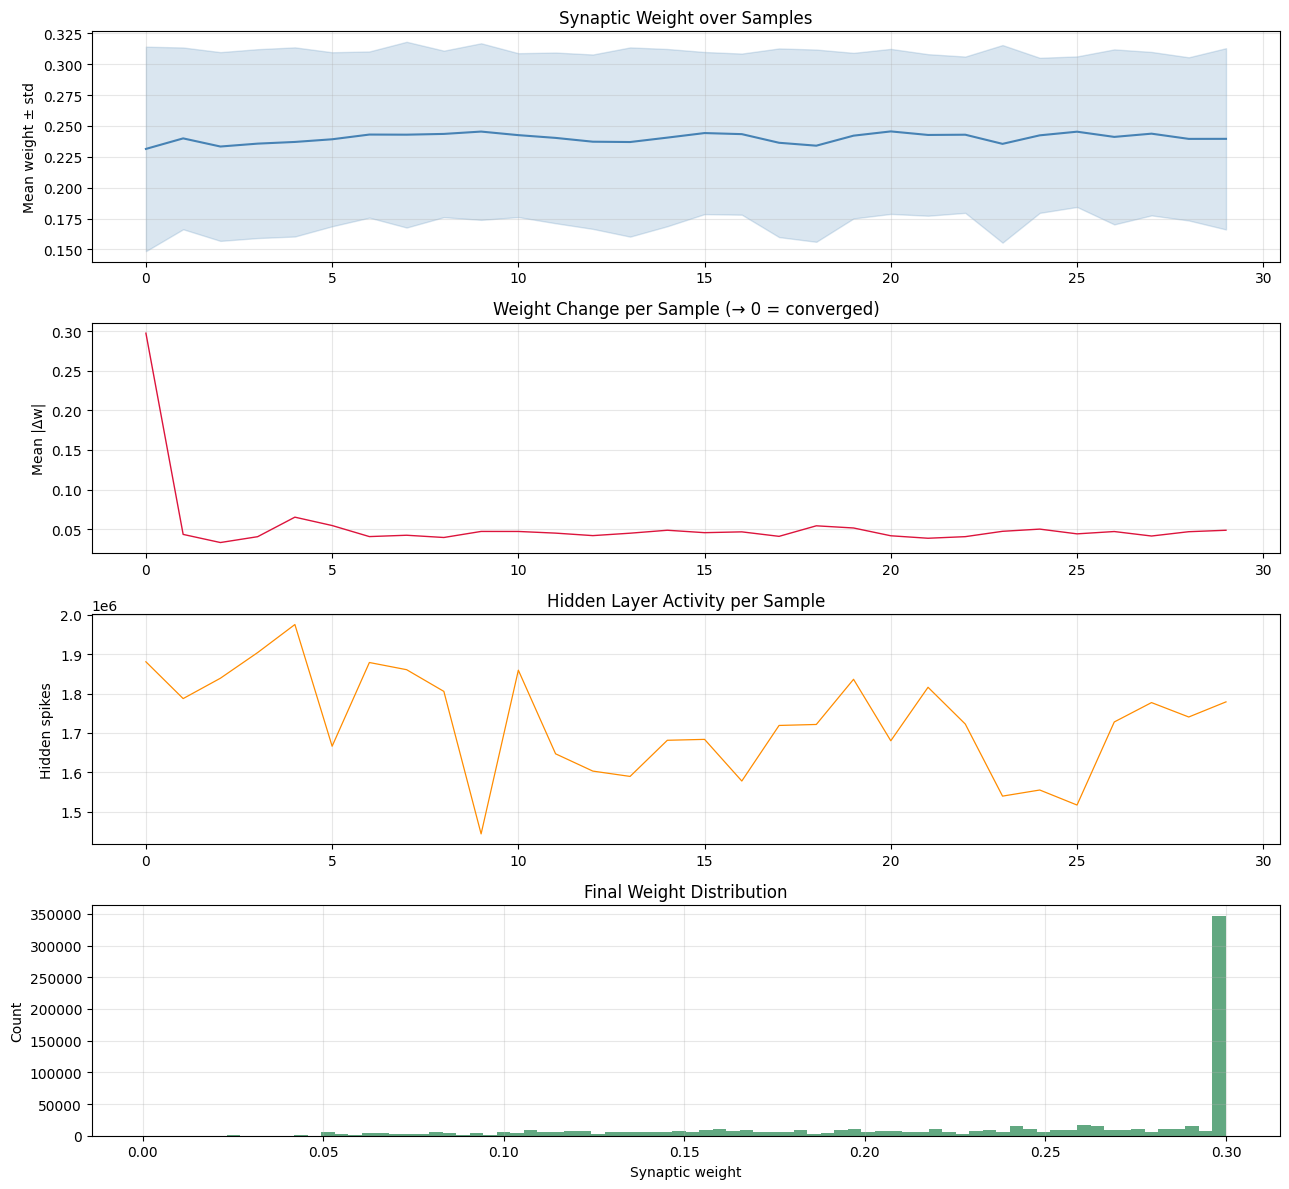

In [7]:
# ==============================
# Convergence Diagnostics
# ==============================
fig, axes = plt.subplots(4, 1, figsize=(13, 12))

x = np.arange(len(history['mean_w']))
mw = np.array(history['mean_w'])
sw = np.array(history['std_w'])

# 1. Mean weight ± std
axes[0].plot(x, mw, color='steelblue', linewidth=1.5)
axes[0].fill_between(x, mw - sw, mw + sw, alpha=0.2, color='steelblue')
axes[0].set_ylabel("Mean weight ± std")
axes[0].set_title("Synaptic Weight over Samples")
axes[0].grid(True, alpha=0.3)

# 2. Mean |Δw| per sample (convergence indicator: should trend → 0)
axes[1].plot(x, history['delta_w'], color='crimson', linewidth=1.0)
axes[1].set_ylabel("Mean |Δw|")
axes[1].set_title("Weight Change per Sample (→ 0 = converged)")
axes[1].grid(True, alpha=0.3)

# 3. Hidden spikes per sample
axes[2].plot(x, history['hidden_spikes'], color='darkorange', linewidth=0.9)
axes[2].set_ylabel("Hidden spikes")
axes[2].set_title("Hidden Layer Activity per Sample")
axes[2].grid(True, alpha=0.3)

# 4. Final weight distribution
axes[3].hist(w_matrix.flatten(), bins=80, color='seagreen', edgecolor='none', alpha=0.75)
axes[3].set_xlabel("Synaptic weight")
axes[3].set_ylabel("Count")
axes[3].set_title("Final Weight Distribution")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

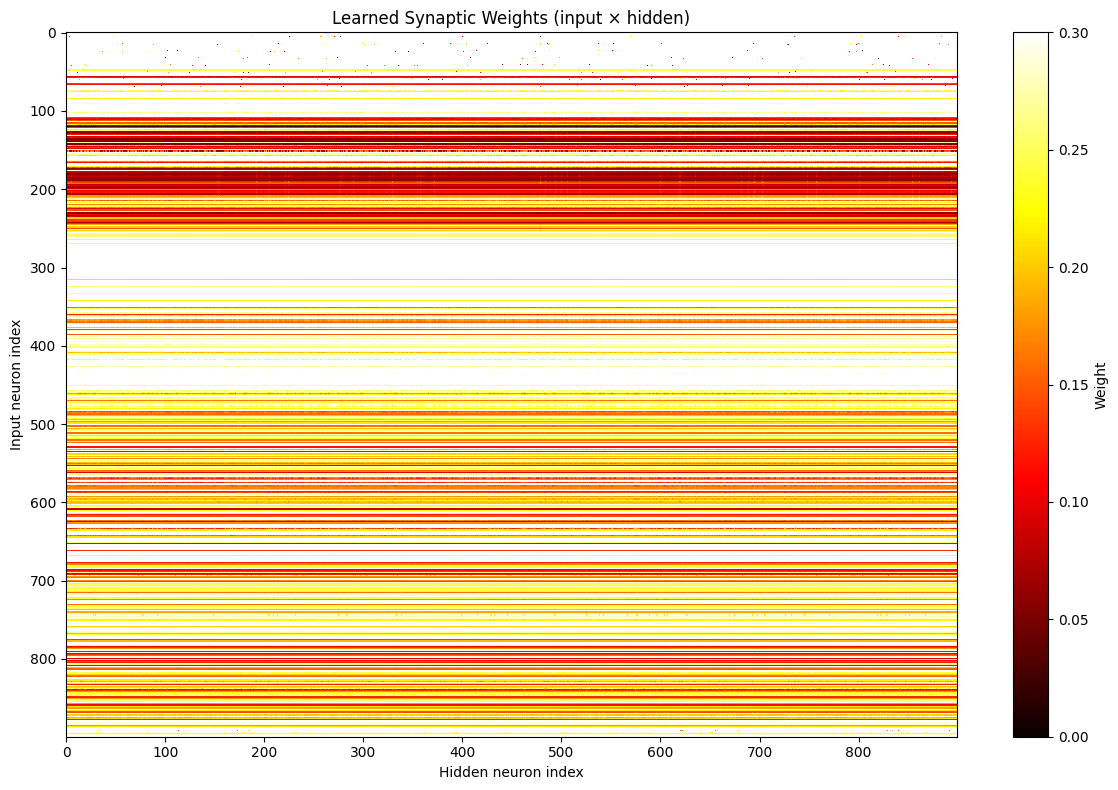

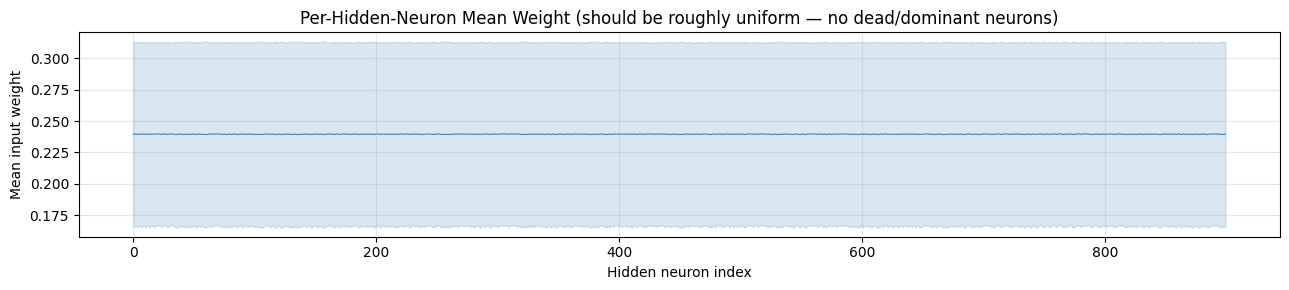

In [8]:
# ==============================
# Weight Matrix Heatmap
# (input neuron × hidden neuron)
# Should show structure — not uniform noise — after training
# ==============================
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(w_matrix, aspect='auto', cmap='hot',
               vmin=wmin, vmax=wmax, interpolation='nearest')
ax.set_xlabel("Hidden neuron index")
ax.set_ylabel("Input neuron index")
ax.set_title("Learned Synaptic Weights (input × hidden)")
fig.colorbar(im, ax=ax, label="Weight")
plt.tight_layout()
plt.show()

# Per-hidden-neuron statistics
per_neuron_mean = w_matrix.mean(axis=0)
per_neuron_std  = w_matrix.std(axis=0)
plt.figure(figsize=(13, 3))
plt.plot(per_neuron_mean, color='steelblue', linewidth=0.8)
plt.fill_between(np.arange(N_H),
                 per_neuron_mean - per_neuron_std,
                 per_neuron_mean + per_neuron_std,
                 alpha=0.2, color='steelblue')
plt.xlabel("Hidden neuron index")
plt.ylabel("Mean input weight")
plt.title("Per-Hidden-Neuron Mean Weight (should be roughly uniform — no dead/dominant neurons)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()